In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

### Load the dataset

In [ ]:
df = pd.read_csv('/content/cleaned_merged_heart_dataset.csv')
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Filter the dataset for `thal=2` and `thal=3`

In [ ]:
filtered_df = df[df['thal'].isin([2, 3])]
display(filtered_df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


### Prepare data for Logistic Regression

In [ ]:
X = filtered_df.drop('target', axis=1)
y = filtered_df['target']

# as 'sex' and 'thal' are already numerical.
if 'sex_text' in X.columns:
    X = X.drop('sex_text', axis=1)
if 'thal_text' in X.columns:
    X = X.drop('thal_text', axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (1163, 13)
Shape of X_test: (499, 13)


### Train the Logistic Regression model

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Evaluate the model

In [ ]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8016

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.72      0.79       253
           1       0.76      0.88      0.81       246

    accuracy                           0.80       499
   macro avg       0.81      0.80      0.80       499
weighted avg       0.81      0.80      0.80       499



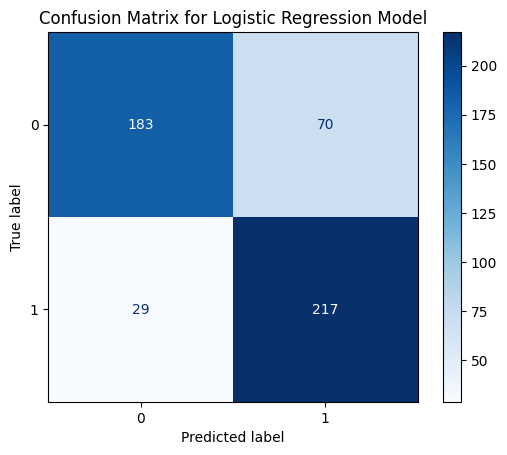

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

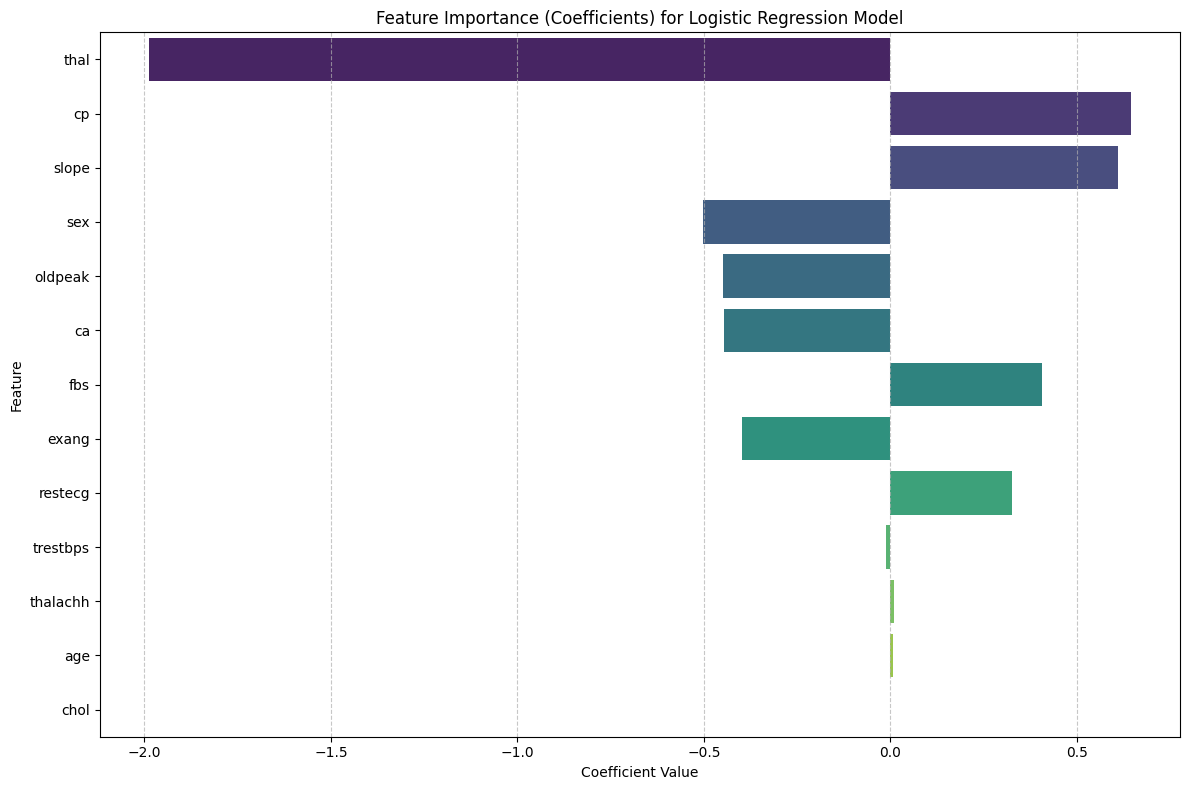

In [12]:
import seaborn as sns

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='coefficient', y='feature', data=feature_importance, palette='viridis', hue='feature', legend=False)
plt.title('Feature Importance (Coefficients) for Logistic Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Feature Importance for Logistic Regression Model

For logistic regression, the coefficients represent the change in the log-odds of the outcome for a one-unit increase in the predictor variable. The absolute magnitude of the coefficients can be used as an indicator of feature importance: larger absolute values imply greater importance.

### Interpretation of the Confusion Matrix

*   **True Negatives (Top-Left):** Correctly predicted negative cases.
*   **False Positives (Top-Right):** Incorrectly predicted positive cases (Type I error).
*   **False Negatives (Bottom-Left):** Incorrectly predicted negative cases (Type II error).
*   **True Positives (Bottom-Right):** Correctly predicted positive cases.

This plot helps in understanding the types of errors made by the model.

### Conclusion of Logistic Regression Model Performance

The Logistic Regression model applied to the filtered dataset (where `thal` is 2 or 3) achieved an accuracy of approximately **80.16%**.

From the classification report, we observe:
*   **Precision and Recall for Class 0 (No Heart Disease):** The model showed a precision of 0.86 and a recall of 0.72. This means that when the model predicts no heart disease, it is correct 86% of the time, and it correctly identifies 72% of all actual no-heart-disease cases.
*   **Precision and Recall for Class 1 (Heart Disease):** The model showed a precision of 0.76 and a recall of 0.88. This indicates that when the model predicts heart disease, it is correct 76% of the time, and it correctly identifies 88% of all actual heart disease cases.

The confusion matrix visually reinforces these points, showing the counts of true positives, true negatives, false positives, and false negatives. The feature importance analysis (based on absolute coefficients) highlights which features contribute most significantly to the model's predictions.

Overall, the model demonstrates reasonable predictive capability for heart disease presence within this specific subset of the data.